In [1]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import seaborn as sns
from programmable_cubes_UDP import ProgrammableCubes
from programmable_cubes_UDP import programmable_cubes_UDP
import numpy as np
from pygmo import problem
import random
from implementation_heuristic import *

## Combination of algorithms to achieve best result


- create udp
- create chromosome
- use find chromosome to apply the method with some parameters
- !!! always call the fitness afterwards to update the cube ensemble

In [9]:
PROBLEM = "JWST"
udp = programmable_cubes_UDP(PROBLEM)
udp.fitness(np.array([-1]))
ti = udp.initial_cube_types
ci = udp.final_cube_positions
ct = udp.target_cube_positions
tt = udp.target_cube_types
types = np.arange(np.max(ti)+1)



In [3]:

def apply_find_chromosome_multiple_times(udp:programmable_cubes_UDP,method=find_chromosome,count=1,chromosome = np.array([])):
    """ 
    udp has to be initialized
    """
    for i in range(count):
        tmp_chrom = method(udp)
        chromosome = np.concatenate([chromosome,tmp_chrom])
        print(udp.fitness(np.concatenate([tmp_chrom,np.array([-1])]),udp.final_cube_positions))
    return chromosome

[np.float64(-0.0)]
mistakes:441+59 budget status: 5.553240779320345 % used, successes: 270
[np.float64(-0.5320649037037037)]
mistakes:198+32 budget status: 1.4399760003999933 % used, successes: 43
[np.float64(-0.6239424)]
mistakes:169+20 budget status: 0.5699905001583307 % used, escape:20.0% successes: 165
mistakes:167+19 budget status: 1.1566473892101798 % used, escape:40.0% successes: 324
mistakes:166+22 budget status: 1.623306278228696 % used, escape:60.0% successes: 483
mistakes:165+20 budget status: 2.1532974450425826 % used, escape:80.0% successes: 644
mistakes:166+20 budget status: 2.5566240562657288 % used, escape:100.0% successes: 805
[np.float64(-0.6143541111111112)]


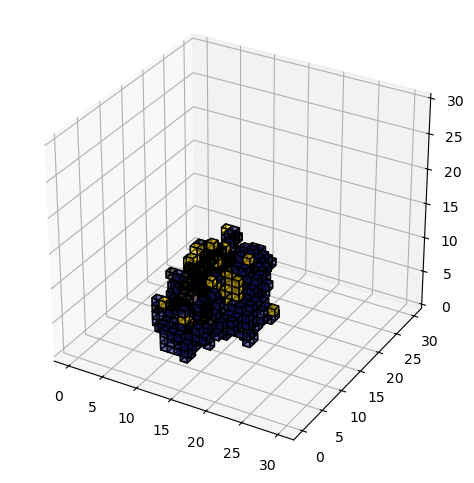

mistakes:168+20 budget status: 0.5399910001499975 % used, escape:20.0% successes: 163
mistakes:168+19 budget status: 0.9766503891601808 % used, escape:40.0% successes: 326
mistakes:168+19 budget status: 1.5033082781953633 % used, escape:60.0% successes: 488
mistakes:166+19 budget status: 2.0966317228046196 % used, escape:80.0% successes: 650
mistakes:167+19 budget status: 2.589956834052766 % used, escape:100.0% successes: 812
[np.float64(-0.6126532888888888)]


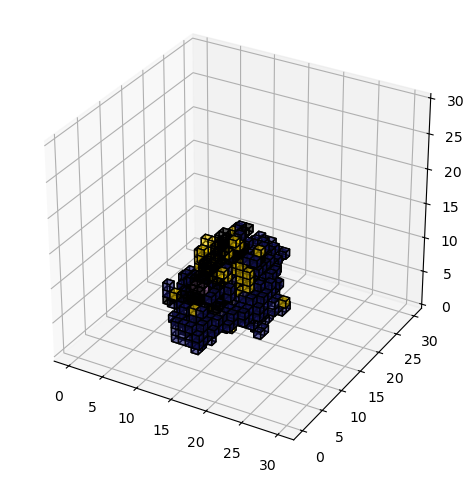

mistakes:169+16 budget status: 0.45999233346110896 % used, successes: 19
[np.float64(-0.667342711111111)]
mistakes:152+14 budget status: 0.0 % used, successes: 0
[np.float64(-0.6679999999999998)]
[np.float64(-0.6499959999999999)]


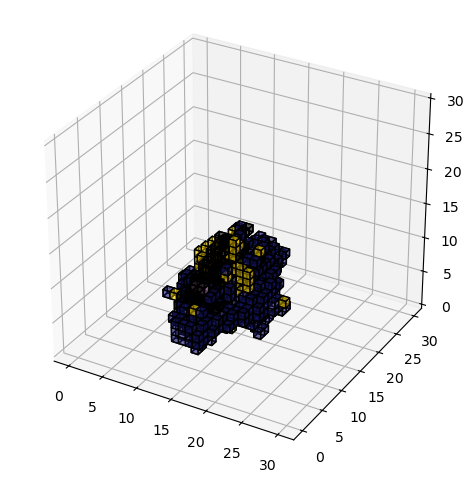

In [15]:
def find_chromosome_heuristic(udp:programmable_cubes_UDP):
    """ 
    Idea:
    mark indices at wrong places and with wrong types only once
    try to move the closest
    extend to further apart
    
    """
    # Initialize cubes
    cubes = ProgrammableCubes(udp.final_cube_positions)
    ti = udp.initial_cube_types
    ci = udp.final_cube_positions
    ct = udp.target_cube_positions
    tt = udp.target_cube_types
    types = np.arange(np.max(ti)+1)

    # Initialize outputs
    chrom = []
    iter = 0
    successes = 0

    # These are part of the structure but with wrong type => need to be moved to allow others move in
    wti = have_wrong_type(cubes.cube_position,ti,ct,tt)
    # wti - wrong type ids, from cube_position
    # These are cubes away from the structure and the hollow points in the structure
    wpi, epi = get_wrong_cube_ids(cubes.cube_position,ct)

    empty_coords = ct[epi]
    empty_coords_types = tt[epi]
    # wpi - wrong place ids, from cube_position
    # epi - empty place ids, from target configuration ct

    # Step 1: move wti to epi
    for id in wti:
        empty_coords_with_correct_type = empty_coords[empty_coords_types==ti[id]]

        start = np.array(cubes.cube_position[id])
        tmp_chrom, tmp_path, success = dijkstra_cubes_multiple(cubes,id,empty_coords_with_correct_type,50)
        if success:
            chrom.extend(tmp_chrom)
            cubes.apply_chromosome(np.concatenate([tmp_chrom,[-1]]),True)
            end = tmp_path[tmp_path.shape[0]-1]
            end_id = contains_coord(empty_coords,end)
            empty_coords = np.delete(empty_coords,end_id,0)
            empty_coords_types = np.delete(empty_coords_types,end_id,0)
            successes += 1

    # Step 2: move move wpi to epi (TODO or wti)
    for id in wpi:
        empty_coords_with_correct_type = empty_coords[empty_coords_types==ti[id]]

        start = np.array(cubes.cube_position[id])
        tmp_chrom, tmp_path, success = dijkstra_cubes_multiple(cubes,id,empty_coords_with_correct_type,50)
        if success:
            chrom.extend(tmp_chrom)
            cubes.apply_chromosome(np.concatenate([tmp_chrom,[-1]]),True)
            end = tmp_path[tmp_path.shape[0]-1]
            end_id = contains_coord(empty_coords,end)
            empty_coords = np.delete(empty_coords,end_id,0)
            empty_coords_types = np.delete(empty_coords_types,end_id,0)
            successes += 1
    

    

    print(f"mistakes:{len(wpi)}+{len(wti)} budget status: {len(chrom)/udp.get_nix()*100} % used, successes: {successes}")
    return np.array(chrom,dtype=int)
print(udp.fitness(np.array([-1])))
chrom = apply_find_chromosome_multiple_times(udp,find_chromosome_heuristic,2)
chrom = np.concatenate([chrom,find_chromosome(udp,pair_colours,axis_search_always_move)])
print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
udp.plot('ensemble', types)
chrom = apply_find_chromosome_multiple_times(udp,find_chromosome_heuristic,2,chrom)
print(udp.fitness(np.concatenate([chrom,np.array([-1])])))
udp.plot('ensemble', types)
#chrom = find_chromosome_heuristic(udp)
#print(chrom)
#chrom = format_chromosome(udp,chrom)



[np.float64(0.0042004888888888935)]


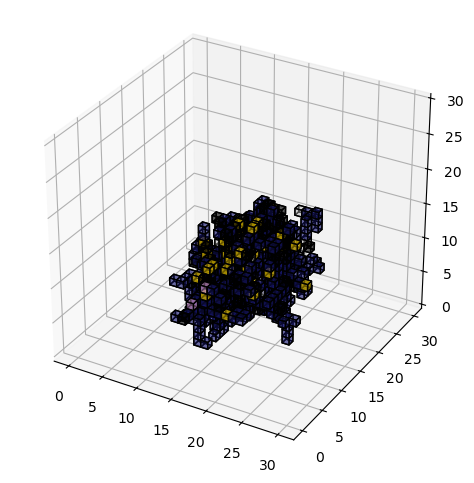

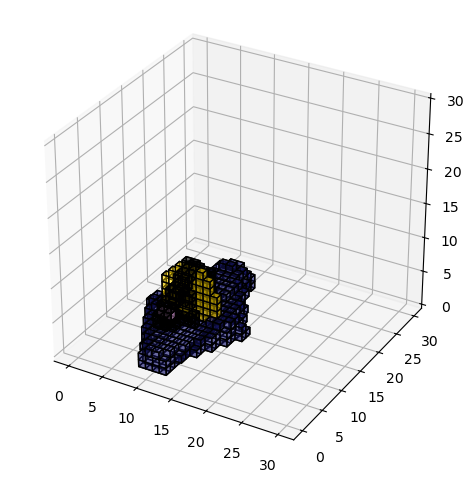

In [ ]:
print(udp.fitness(end_chromosome(chrom)))

In [ ]:
chromosome = find_chromosome(udp,pair_colours,axis_search)
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search_always_move)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,axis_search_always_move)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)
chromosome = np.concatenate([chromosome,find_chromosome(udp,pair_colours,astar_cubes)])
print(udp.fitness(np.concatenate([chromosome,np.array([-1])])))
udp.plot('ensemble', types)

udp.fitness(np.array([-1]))
chromosome = format_chromosome(udp,chromosome)
print(udp.fitness(chromosome))

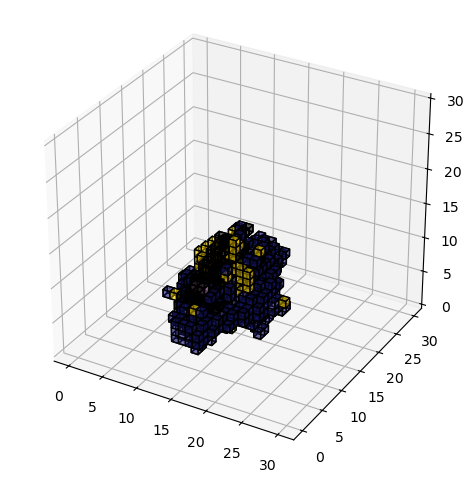

In [16]:
np.save("chromosome_jwst",chrom)
udp.plot('ensemble', types)

In [21]:
def save_setup_in_time(udp:programmable_cubes_UDP,chromosome:np.ndarray,frames=5):
    udp.fitness(np.array([-1]))
    num_of_moves = len(chromosome)/2
    for i in np.arange(frames):
        partial_chromosome = chromosome[:(int)(i*num_of_moves/frames)*2]
        print(len(partial_chromosome))
        udp.fitness(end_chromosome(partial_chromosome))
        np.save(f"out_{i}",udp.final_cube_positions)
print(len(chrom))

save_setup_in_time(udp,chrom)

7560
0
1512
3024
4536
6048


In [ ]:
# save to vdb

# import numpy as np
# import openvdb as vdb   # alias so it looks like "openvdb"

# coords = udp.final_cube_positions
# types  = udp.initial_cube_types

# grid = vdb.FloatGrid()
# grid.name = "voxels"

# acc = grid.getAccessor()
# for (x, y, z), t in zip(coords, types):
#     acc.setValueOn((x, y, z), t)

# vdb.write("voxels.vdb", grids=[grid])